# Titanic Survival Prediction - Logistic Regression



## 1. Imports and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('all imports loaded')


all imports loaded


## 2. Load Data

In [2]:
# Load Titanic dataset from seaborn's built-in datasets
df = sns.load_dataset('titanic')

# Keep the relevant raw columns
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'alone']]
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)


Dataset shape: (891, 11)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False


In [3]:
df.describe().round(2)


,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [4]:
print('Missing values:')
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Missing Count'] > 0])


Missing values:
          Missing Count  Missing %
age                 177      19.87
embarked              2       0.22


## 3. EDA (Exploratory Data Analysis)

### 3.1 Target Variable (Survived)

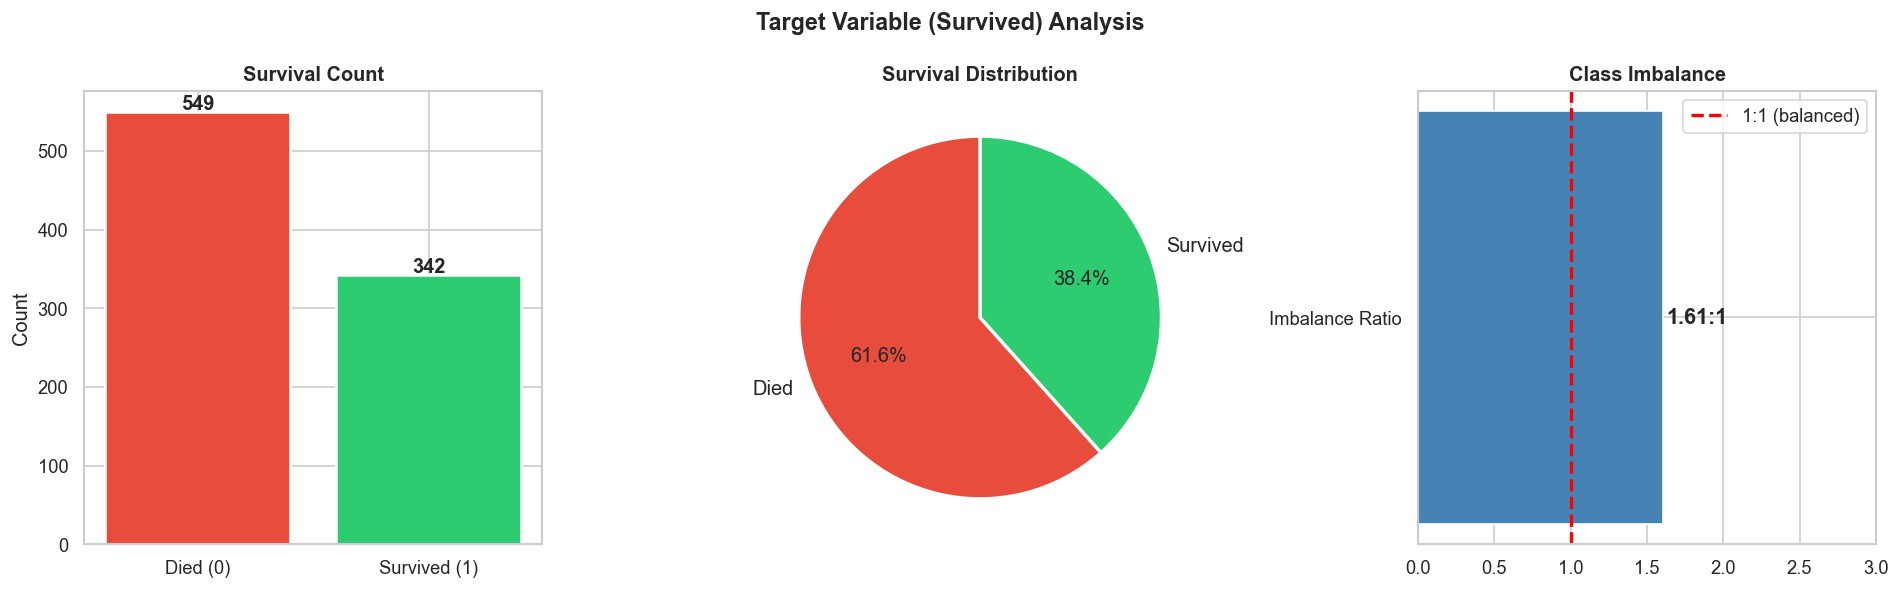

Survival rate: 38.4%
Class imbalance is moderate  use stratified split and check recall per class.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Count plot
survived_counts = df['survived'].value_counts()
bars = axes[0].bar(['Died (0)', 'Survived (1)'], survived_counts.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, survived_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(count), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Survival Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(survived_counts.values, labels=['Died', 'Survived'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Survival Distribution', fontsize=12, fontweight='bold')

# Class imbalance bar
imbalance_ratio = survived_counts[0] / survived_counts[1]
axes[2].barh(['Imbalance Ratio'], [imbalance_ratio], color='steelblue', height=0.4)
axes[2].axvline(1, color='red', linestyle='--', linewidth=2, label='1:1 (balanced)')
axes[2].text(imbalance_ratio + 0.02, 0, f'{imbalance_ratio:.2f}:1',
             va='center', fontsize=13, fontweight='bold')
axes[2].set_title('Class Imbalance', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, 3)
axes[2].legend()

plt.suptitle('Target Variable (Survived) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Survival rate: {df["survived"].mean()*100:.1f}%')
print('Class imbalance is moderate  use stratified split and check recall per class.')


### 3.2 Survival by Gender

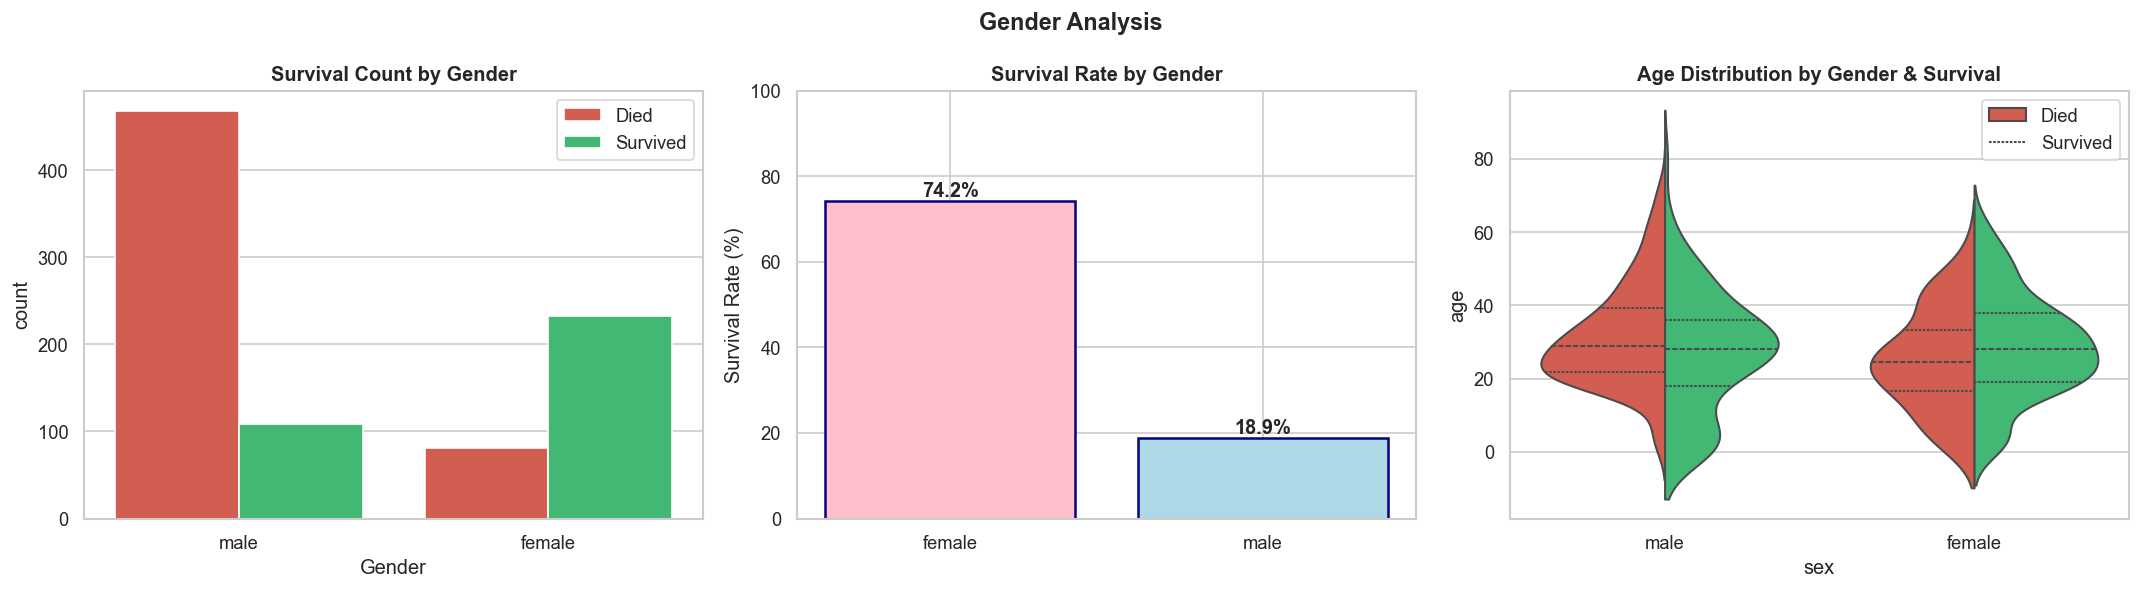

 "Women and children first" was clearly followed in evacuation.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Survival count by sex
sns.countplot(data=df, x='sex', hue='survived', palette=['#e74c3c', '#2ecc71'],
              edgecolor='white', ax=axes[0])
axes[0].set_title('Survival Count by Gender', fontsize=12, fontweight='bold')
axes[0].legend(['Died', 'Survived'])
axes[0].set_xlabel('Gender')

# Survival rate by sex
sex_rate = df.groupby('sex')['survived'].mean() * 100
bars = axes[1].bar(sex_rate.index, sex_rate.values,
                   color=['lightblue' if s == 'male' else 'pink' for s in sex_rate.index],
                   edgecolor='navy', linewidth=1.5)
for bar, v in zip(bars, sex_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)

# Violin  Age distribution by sex and survival
sns.violinplot(data=df, x='sex', y='age', hue='survived',
               split=True, palette=['#e74c3c', '#2ecc71'],
               inner='quart', ax=axes[2])
axes[2].set_title('Age Distribution by Gender & Survival', fontsize=12, fontweight='bold')
axes[2].legend(['Died', 'Survived'])

plt.suptitle('Gender Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print(' "Women and children first" was clearly followed in evacuation.')


### 3.3 Survival by Class

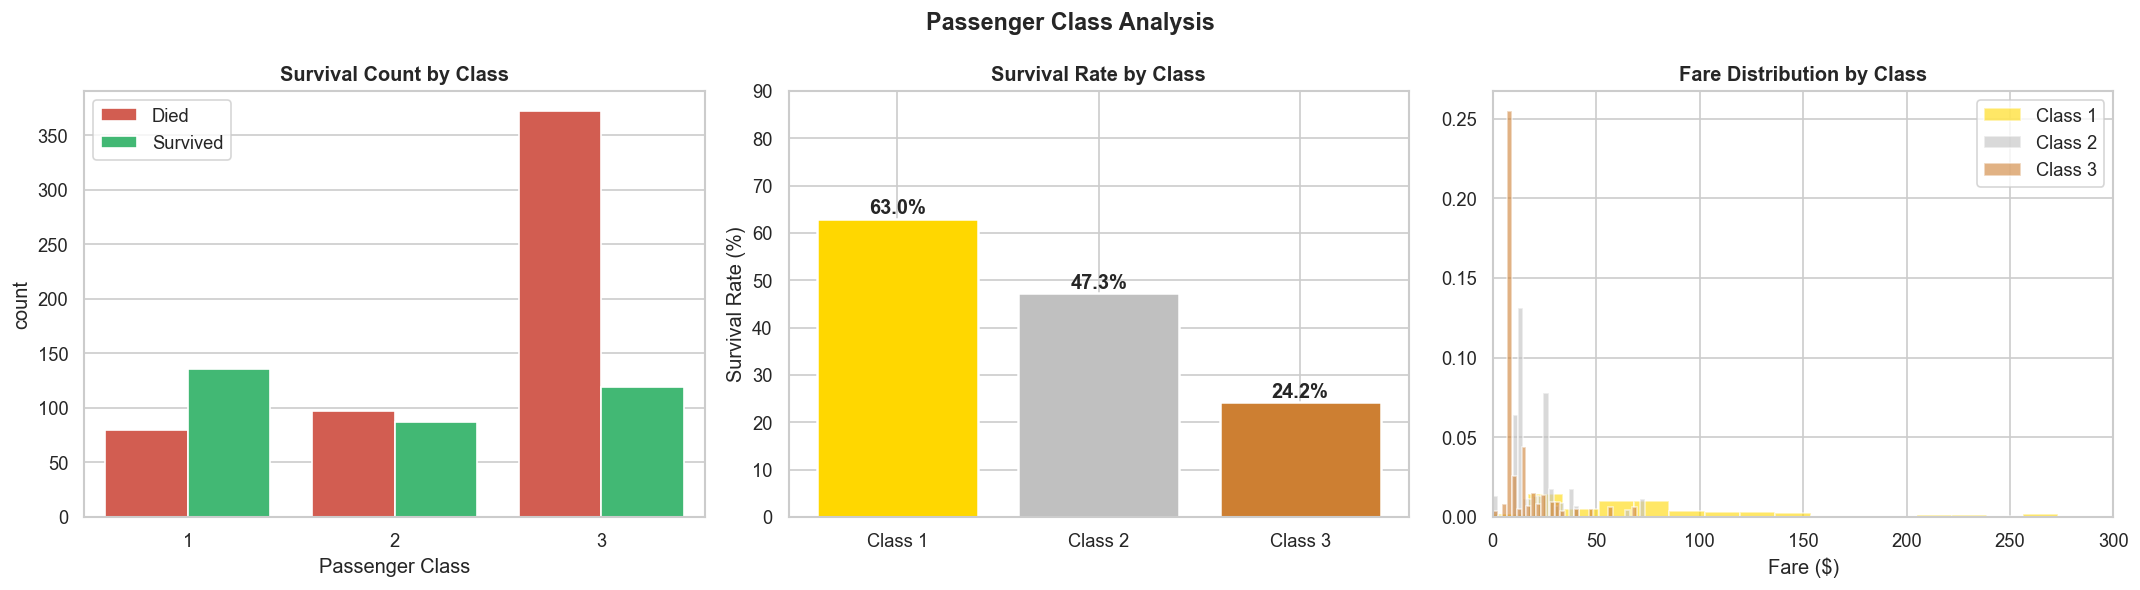

Higher class had priority and better cabin location for liferafts


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count by class and survival
sns.countplot(data=df, x='pclass', hue='survived', palette=['#e74c3c', '#2ecc71'],
              edgecolor='white', ax=axes[0])
axes[0].set_title('Survival Count by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].legend(['Died', 'Survived'])

# Survival rate by class
class_rate = df.groupby('pclass')['survived'].mean() * 100
colors_class = ['gold', 'silver', '#cd7f32']
bars = axes[1].bar([f'Class {i}' for i in class_rate.index], class_rate.values,
                   color=colors_class, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, class_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Survival Rate by Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 90)

# Fare distribution by class
for i, cls in enumerate([1, 2, 3]):
    data = df[df['pclass'] == cls]['fare'].dropna()
    axes[2].hist(data, bins=30, alpha=0.6, label=f'Class {cls}', color=colors_class[i], density=True)
axes[2].set_title('Fare Distribution by Class', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fare ($)')
axes[2].legend()
axes[2].set_xlim(0, 300)

plt.suptitle('Passenger Class Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print('Higher class had priority and better cabin location for liferafts')


### 3.4 Age Analysis

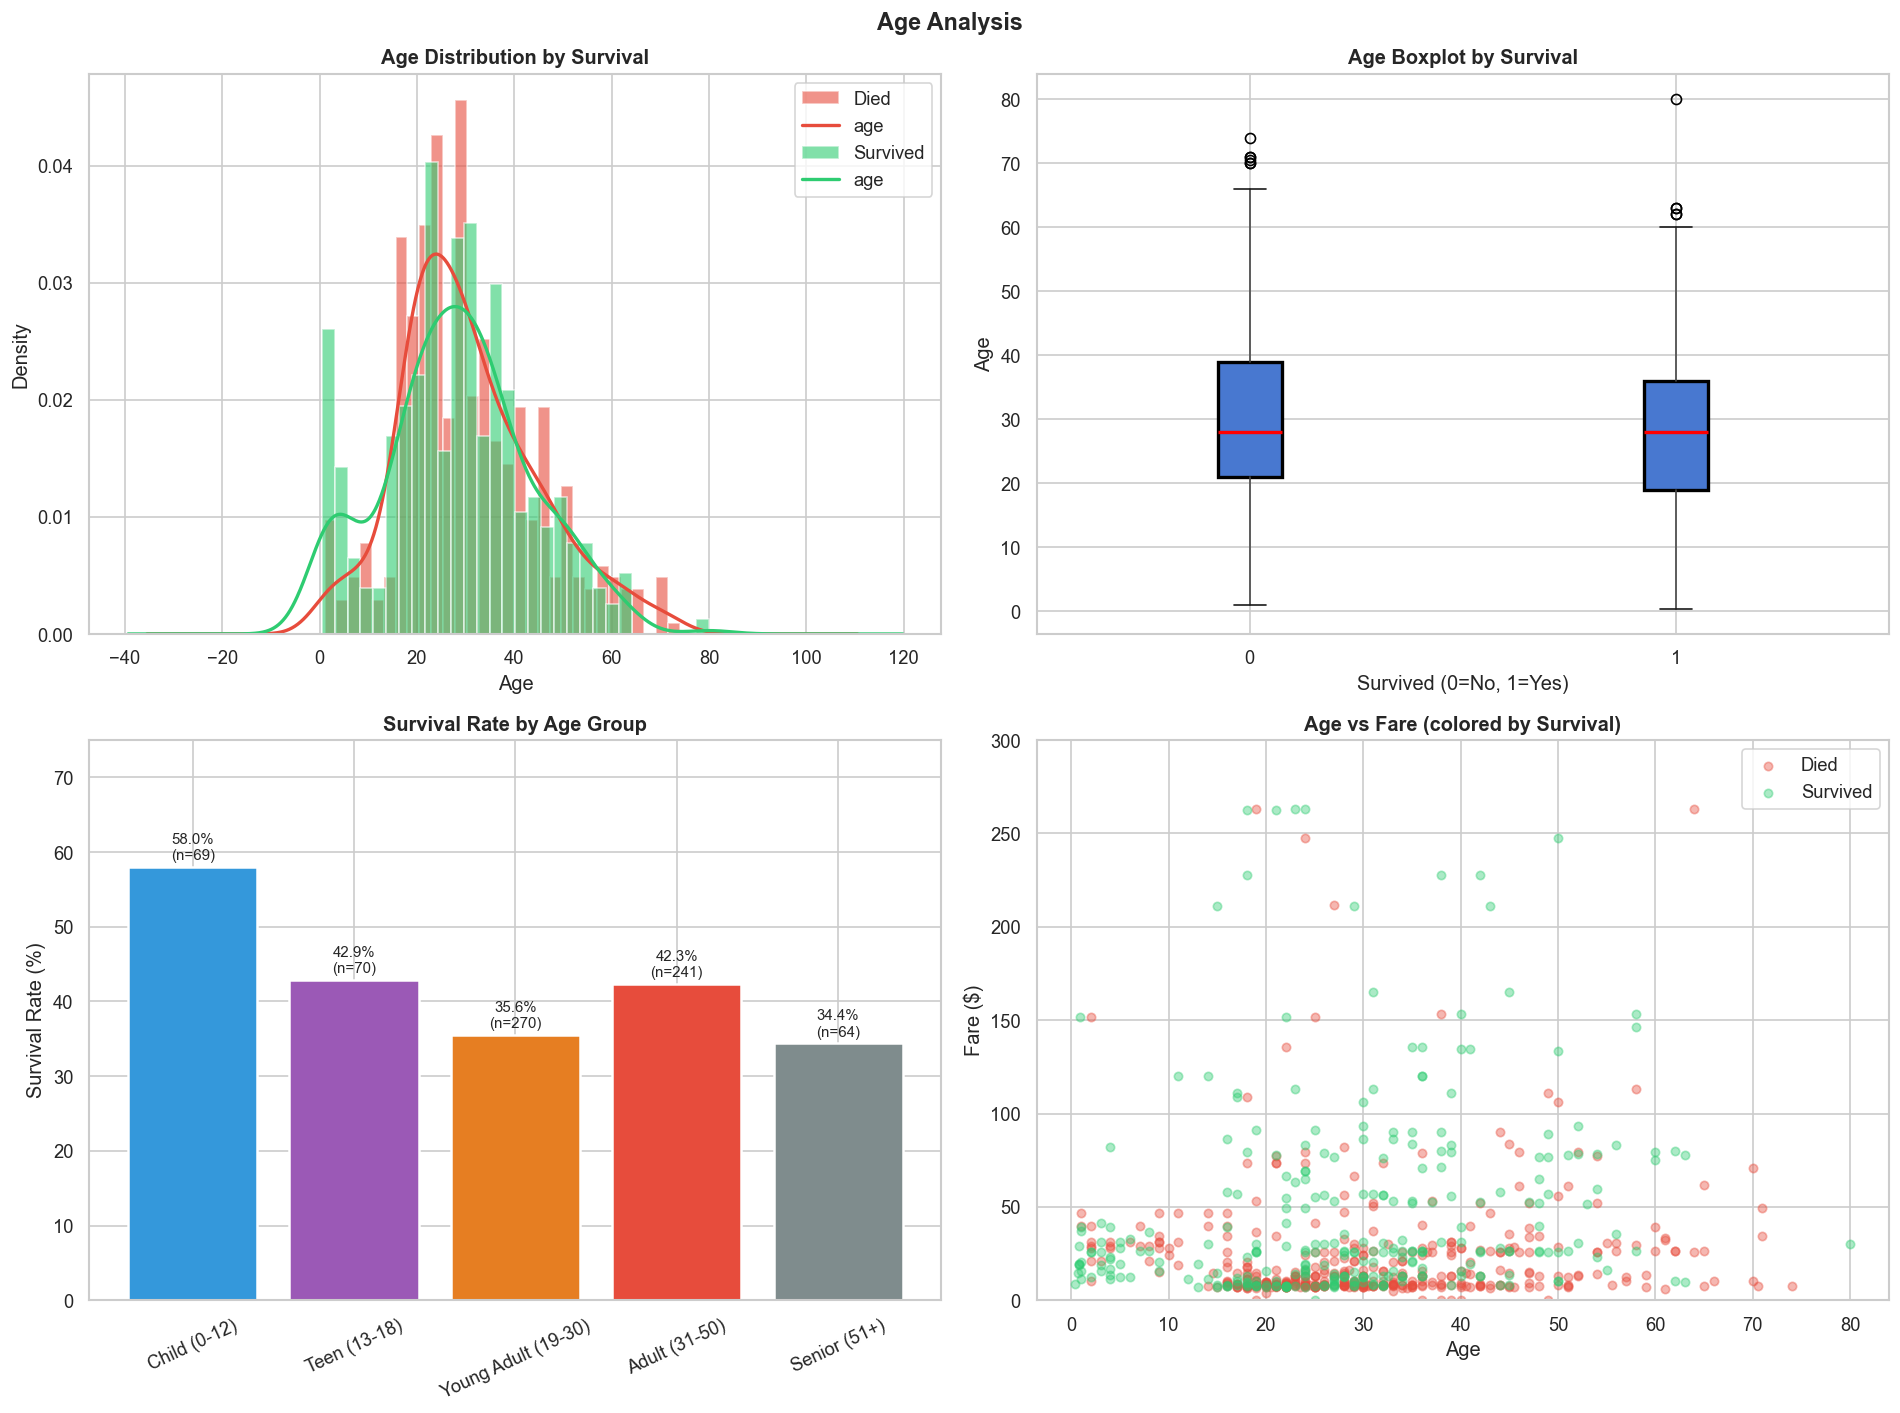

 Children (0-12) had the highest survival rate  consistent with "children first" policy.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution by survival
for s, color, label in [(0, '#e74c3c', 'Died'), (1, '#2ecc71', 'Survived')]:
    data = df[df['survived'] == s]['age'].dropna()
    axes[0, 0].hist(data, bins=30, alpha=0.6, color=color, label=label, density=True, edgecolor='white')
    data.plot(kind='kde', ax=axes[0, 0], color=color, linewidth=2)
axes[0, 0].set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].legend()

# Age boxplot by survival
df.boxplot(column='age', by='survived', ax=axes[0, 1],
           boxprops=dict(linewidth=2),
           medianprops=dict(color='red', linewidth=2),
           patch_artist=True)
axes[0, 1].set_title('Age Boxplot by Survival', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Survived (0=No, 1=Yes)')
axes[0, 1].set_ylabel('Age')

# Age groups survival rate
df_age = df.dropna(subset=['age']).copy()
df_age['age_group'] = pd.cut(df_age['age'],
                              bins=[0, 12, 18, 30, 50, 80],
                              labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-30)',
                                      'Adult (31-50)', 'Senior (51+)'])
age_survival = df_age.groupby('age_group')['survived'].agg(['mean', 'count'])
age_survival['mean'] *= 100

axes[1, 0].bar(age_survival.index, age_survival['mean'],
               color=['#3498db', '#9b59b6', '#e67e22', '#e74c3c', '#7f8c8d'],
               edgecolor='white', linewidth=1.5)
for i, (idx, row) in enumerate(age_survival.iterrows()):
    axes[1, 0].text(i, row['mean'] + 1, f'{row["mean"]:.1f}%\n(n={int(row["count"])})',
                    ha='center', fontsize=9)
axes[1, 0].set_title('Survival Rate by Age Group', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Survival Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=25)
axes[1, 0].set_ylim(0, 75)

# Age vs Fare scatter colored by survival
for s, color, label in [(0, '#e74c3c', 'Died'), (1, '#2ecc71', 'Survived')]:
    mask = df['survived'] == s
    axes[1, 1].scatter(df[mask]['age'], df[mask]['fare'],
                       alpha=0.4, s=25, color=color, label=label)
axes[1, 1].set_title('Age vs Fare (colored by Survival)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Fare ($)')
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 300)

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Children (0-12) had the highest survival rate  consistent with "children first" policy.')


### 3.5 Port & Family size

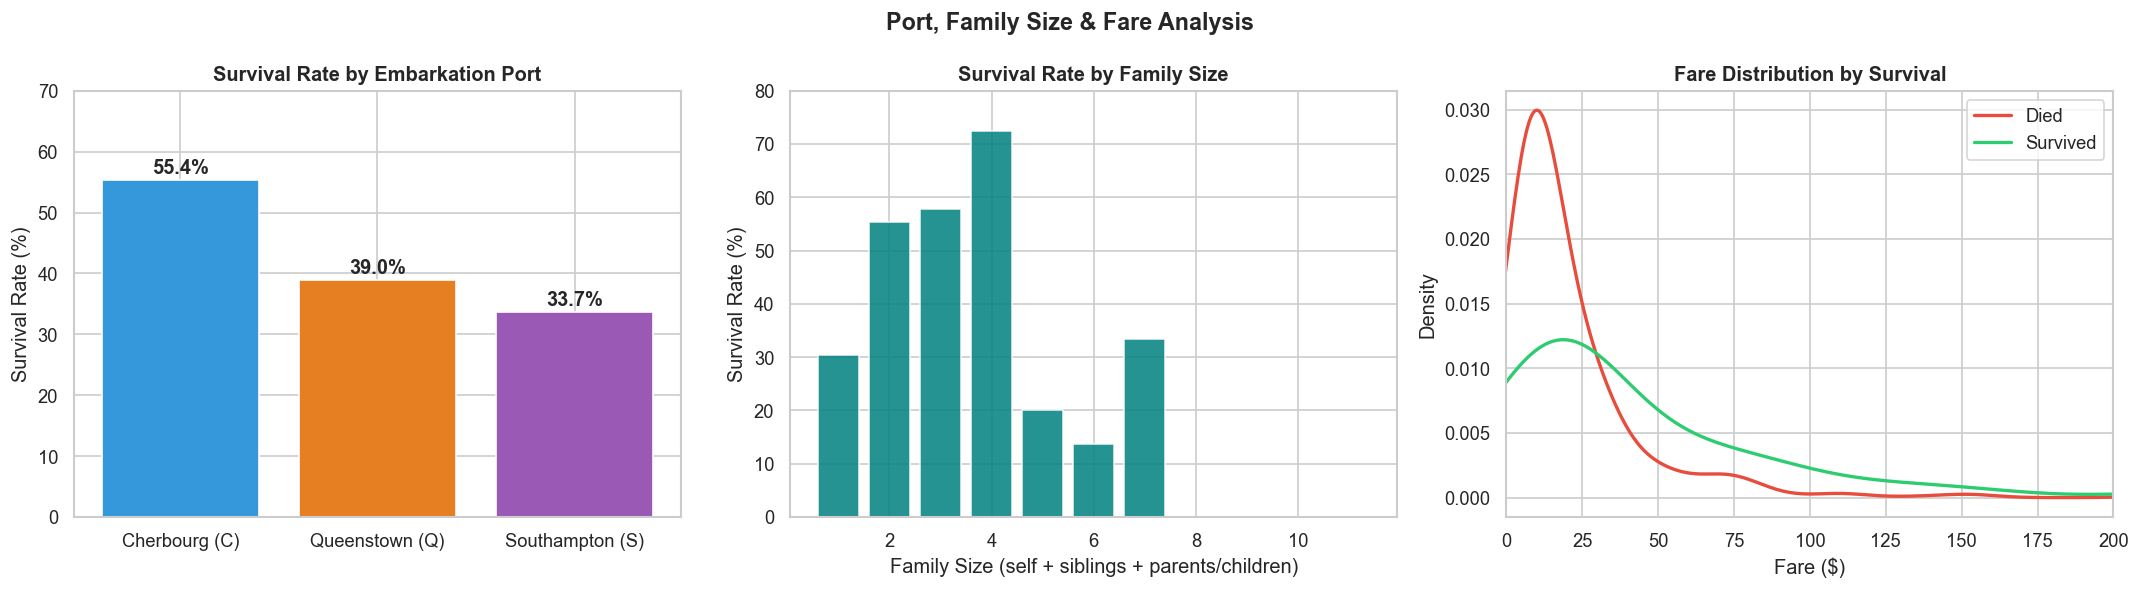

Cherbourg embarked passengers had higher survival rates likely due to class


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Embarked
emb_rate = df.dropna(subset=['embarked']).groupby('embarked')['survived'].mean() * 100
port_names = {'C': 'Cherbourg (C)', 'Q': 'Queenstown (Q)', 'S': 'Southampton (S)'}
axes[0].bar([port_names[k] for k in emb_rate.index], emb_rate.values,
            color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='white')
for i, v in enumerate(emb_rate.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Survival Rate by Embarkation Port', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 70)

# Family size
df['family_size'] = df['sibsp'] + df['parch'] + 1
fam_rate = df.groupby('family_size')['survived'].mean() * 100
axes[1].bar(fam_rate.index, fam_rate.values, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Family Size (self + siblings + parents/children)')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)

# Fare distribution by survival
df[df['survived'] == 0]['fare'].dropna().plot(kind='kde', ax=axes[2],
                                               color='#e74c3c', linewidth=2, label='Died')
df[df['survived'] == 1]['fare'].dropna().plot(kind='kde', ax=axes[2],
                                               color='#2ecc71', linewidth=2, label='Survived')
axes[2].set_title('Fare Distribution by Survival', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fare ($)')
axes[2].set_xlim(0, 200)
axes[2].legend()

plt.suptitle('Port, Family Size & Fare Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Cherbourg embarked passengers had higher survival rates likely due to class')


### 3.6 Cross-features

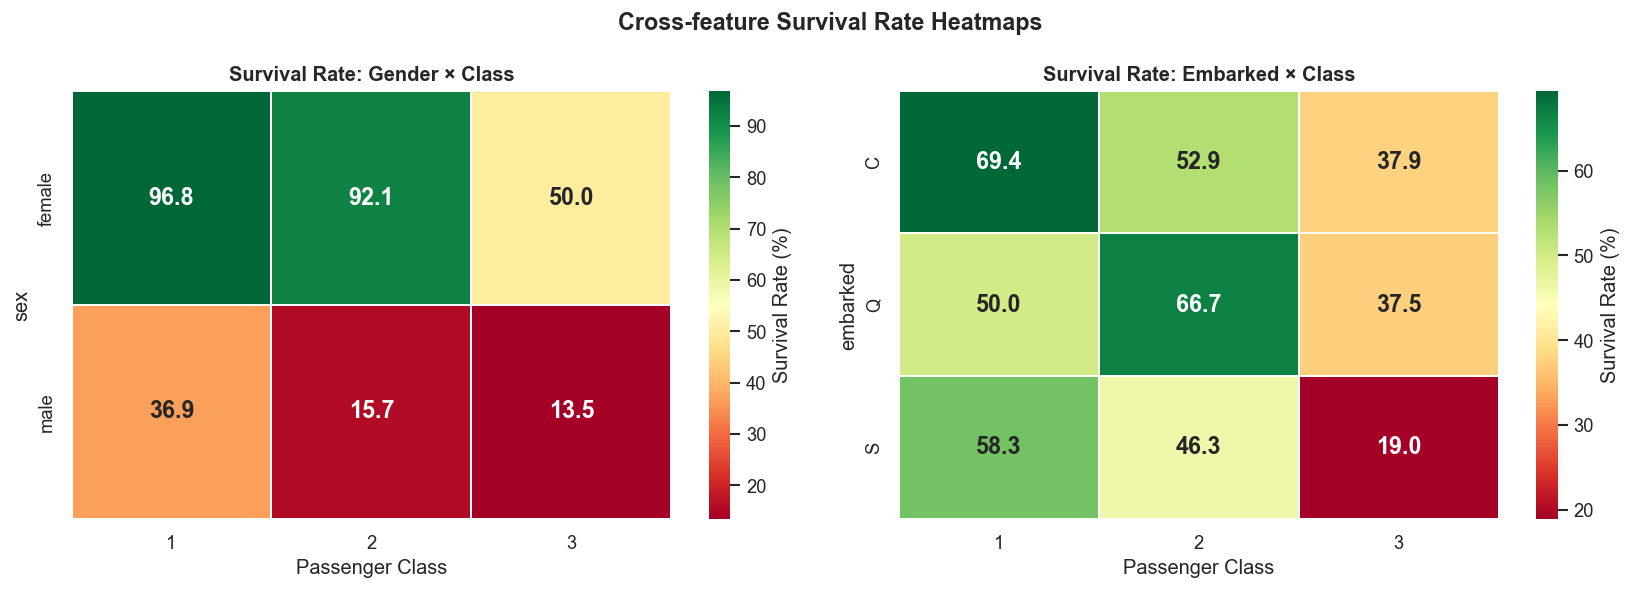

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap: Class x Sex survival rate
pivot = df.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=1, ax=axes[0], cbar_kws={'label': 'Survival Rate (%)'},
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Survival Rate: Gender × Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')

# Heatmap: Class x Embarked
pivot2 = df.dropna(subset=['embarked']).pivot_table(
    values='survived', index='embarked', columns='pclass', aggfunc='mean') * 100
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=1, ax=axes[1], cbar_kws={'label': 'Survival Rate (%)'},
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Survival Rate: Embarked × Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')

plt.suptitle('Cross-feature Survival Rate Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.7 Correlations

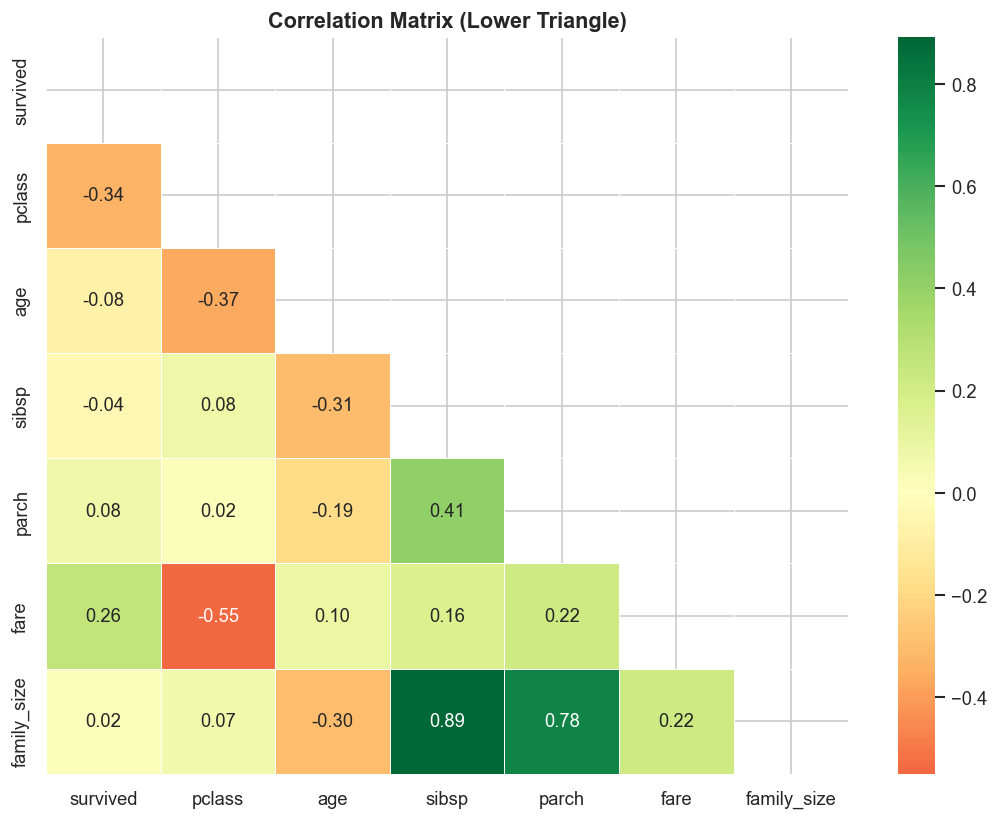

Correlation with survived:
pclass        -0.338481
fare           0.257307
parch          0.081629
age           -0.077221
sibsp         -0.035322
family_size    0.016639
Name: survived, dtype: float64


In [11]:
df_corr = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']].copy()

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with survived:')
print(corr['survived'].drop('survived').sort_values(key=abs, ascending=False))


## 4. Preprocessing & Feature Engineering

In [12]:
df_model = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

# Feature engineering
df_model['family_size'] = df_model['sibsp'] + df_model['parch'] + 1
df_model['is_alone'] = (df_model['family_size'] == 1).astype(int)
df_model['fare_log'] = np.log1p(df_model['fare'])  # log transform to reduce skew

# Encode sex
df_model['sex_enc'] = (df_model['sex'] == 'male').astype(int)

# Embarked: impute missing and encode
df_model['embarked'] = df_model['embarked'].fillna('S')
embarked_dummies = pd.get_dummies(df_model['embarked'], prefix='emb', drop_first=True)
df_model = pd.concat([df_model, embarked_dummies], axis=1)

# Select final features
feature_cols = ['pclass', 'sex_enc', 'age', 'fare_log', 'family_size', 'is_alone',
                'emb_Q', 'emb_S']

X = df_model[feature_cols]
y = df_model['survived']

# Impute missing age with median
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

# Standardize
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Train-Test Split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train survival rate: {y_train.mean():.3f} | Test survival rate: {y_test.mean():.3f}')


Train: (712, 8) | Test: (179, 8)
Train survival rate: 0.383 | Test survival rate: 0.385


## 5. Logistic Regression from Scratch

Building a basic logistic regression classifier using gradient descent and sigmoid.

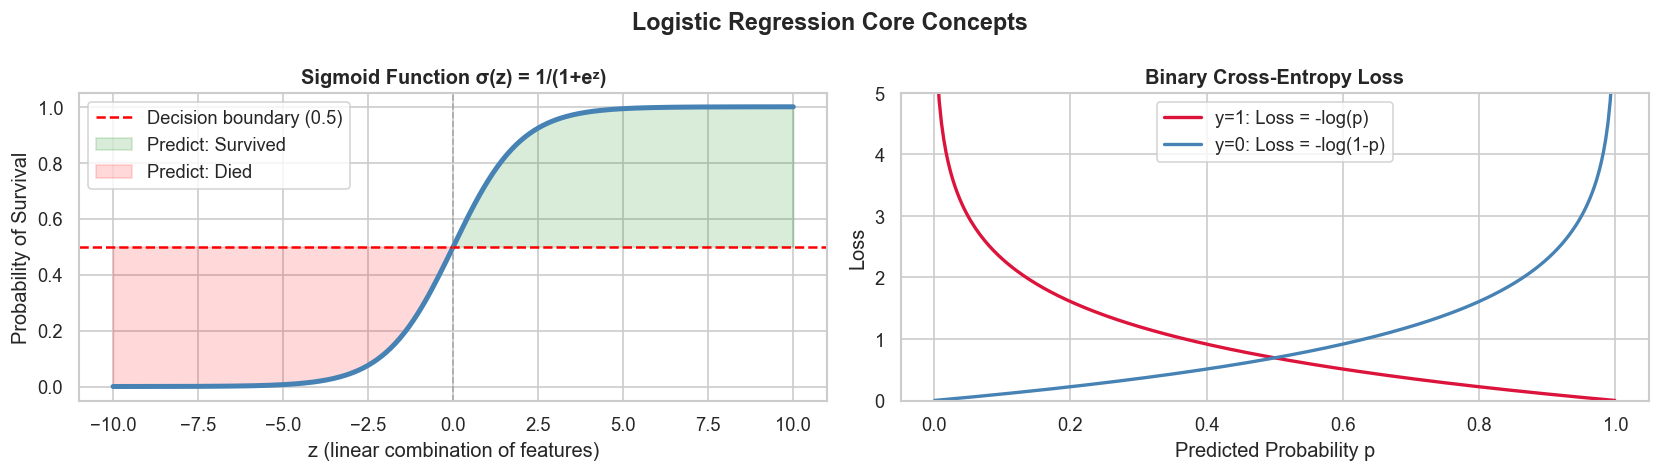

In [13]:
# Visualize the sigmoid function
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

axes[0].plot(z, sigmoid, color='steelblue', linewidth=3)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision boundary (0.5)')
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.15, color='green', label='Predict: Survived')
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.15, color='red', label='Predict: Died')
axes[0].set_title('Sigmoid Function σ(z) = 1/(1+eᶻ)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('z (linear combination of features)')
axes[0].set_ylabel('Probability of Survival')
axes[0].legend()
axes[0].set_ylim(-0.05, 1.05)

# Cross-entropy loss
p = np.linspace(0.001, 0.999, 300)
axes[1].plot(p, -np.log(p), color='crimson', linewidth=2, label='y=1: Loss = -log(p)')
axes[1].plot(p, -np.log(1-p), color='steelblue', linewidth=2, label='y=0: Loss = -log(1-p)')
axes[1].set_title('Binary Cross-Entropy Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Probability p')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].set_ylim(0, 5)

plt.suptitle('Logistic Regression Core Concepts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


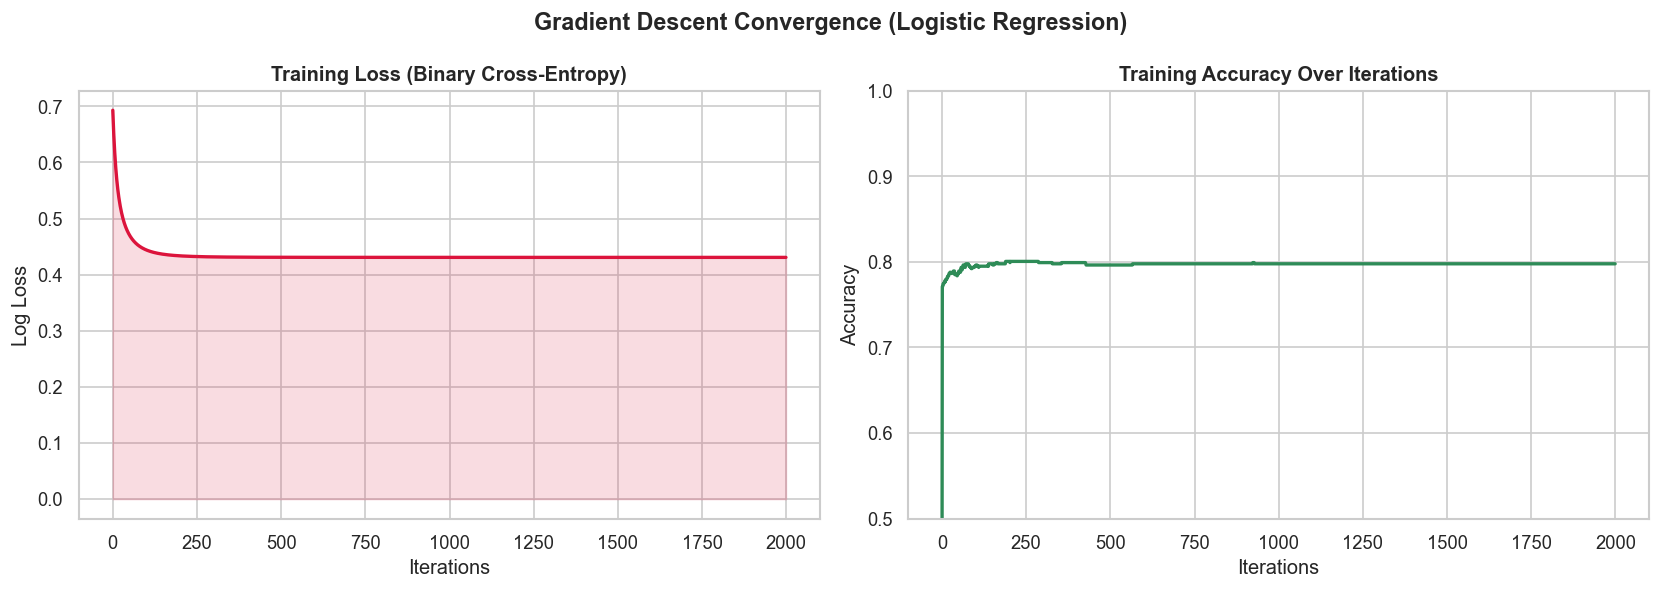

Scratch Logistic Regression  Test Accuracy: 0.8045


In [14]:
class LogisticRegressionScratch:
    """Logistic Regression from scratch using Gradient Descent."""
    
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.acc_history = []
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        y = np.array(y)
        
        for i in range(self.n_iter):
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)
            
            dw = (1/m) * X.T @ (y_pred - y)
            db = (1/m) * np.sum(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Log loss
            loss = -(1/m) * np.sum(
                y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15)
            )
            acc = np.mean((y_pred >= 0.5) == y)
            self.loss_history.append(loss)
            self.acc_history.append(acc)
        
        return self
    
    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


lr_scratch = LogisticRegressionScratch(lr=0.1, n_iter=2000)
lr_scratch.fit(X_train.values, y_train.values)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_scratch.loss_history, color='crimson', linewidth=2)
axes[0].fill_between(range(len(lr_scratch.loss_history)),
                     lr_scratch.loss_history, alpha=0.15, color='crimson')
axes[0].set_title('Training Loss (Binary Cross-Entropy)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Log Loss')

axes[1].plot(lr_scratch.acc_history, color='seagreen', linewidth=2)
axes[1].set_title('Training Accuracy Over Iterations', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)

plt.suptitle('Gradient Descent Convergence (Logistic Regression)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

scratch_pred = lr_scratch.predict(X_test.values)
print(f'Scratch Logistic Regression  Test Accuracy: {accuracy_score(y_test, scratch_pred):.4f}')


## 6. sklearn Logistic Regression

In [15]:
# Baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

# Stratified K-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(log_reg, X_scaled, y, cv=skf, scoring='accuracy')
cv_roc = cross_val_score(log_reg, X_scaled, y, cv=skf, scoring='roc_auc')

print('sklearn Logistic Regression results:')
print(f'Test Accuracy:           {accuracy_score(y_test, y_pred):.4f}')
print(f'5-Fold CV Accuracy:      {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'5-Fold CV ROC-AUC:       {cv_roc.mean():.4f} ± {cv_roc.std():.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))


sklearn Logistic Regression results:
Test Accuracy:           0.8045
5-Fold CV Accuracy:      0.7991 ± 0.0105
5-Fold CV ROC-AUC:       0.8569 ± 0.0196

              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## 🛡️ 7. Regularization  L1 (Lasso), L2 (Ridge)

In logistic regression, regularization is controlled by parameter **C = 1/λ** (inverse of regularization strength):
- **Small C** = strong regularization (simpler model, may underfit)
- **Large C** = weak regularization (complex model, may overfit)

| Penalty | sklearn param | Effect |
|---------|--------------|--------|
| L2 (Ridge) | `penalty='l2'` | Default. Shrinks all coefficients. Keeps all features. |
| L1 (Lasso) | `penalty='l1'` | Can zero out coefficients. Feature selection. |

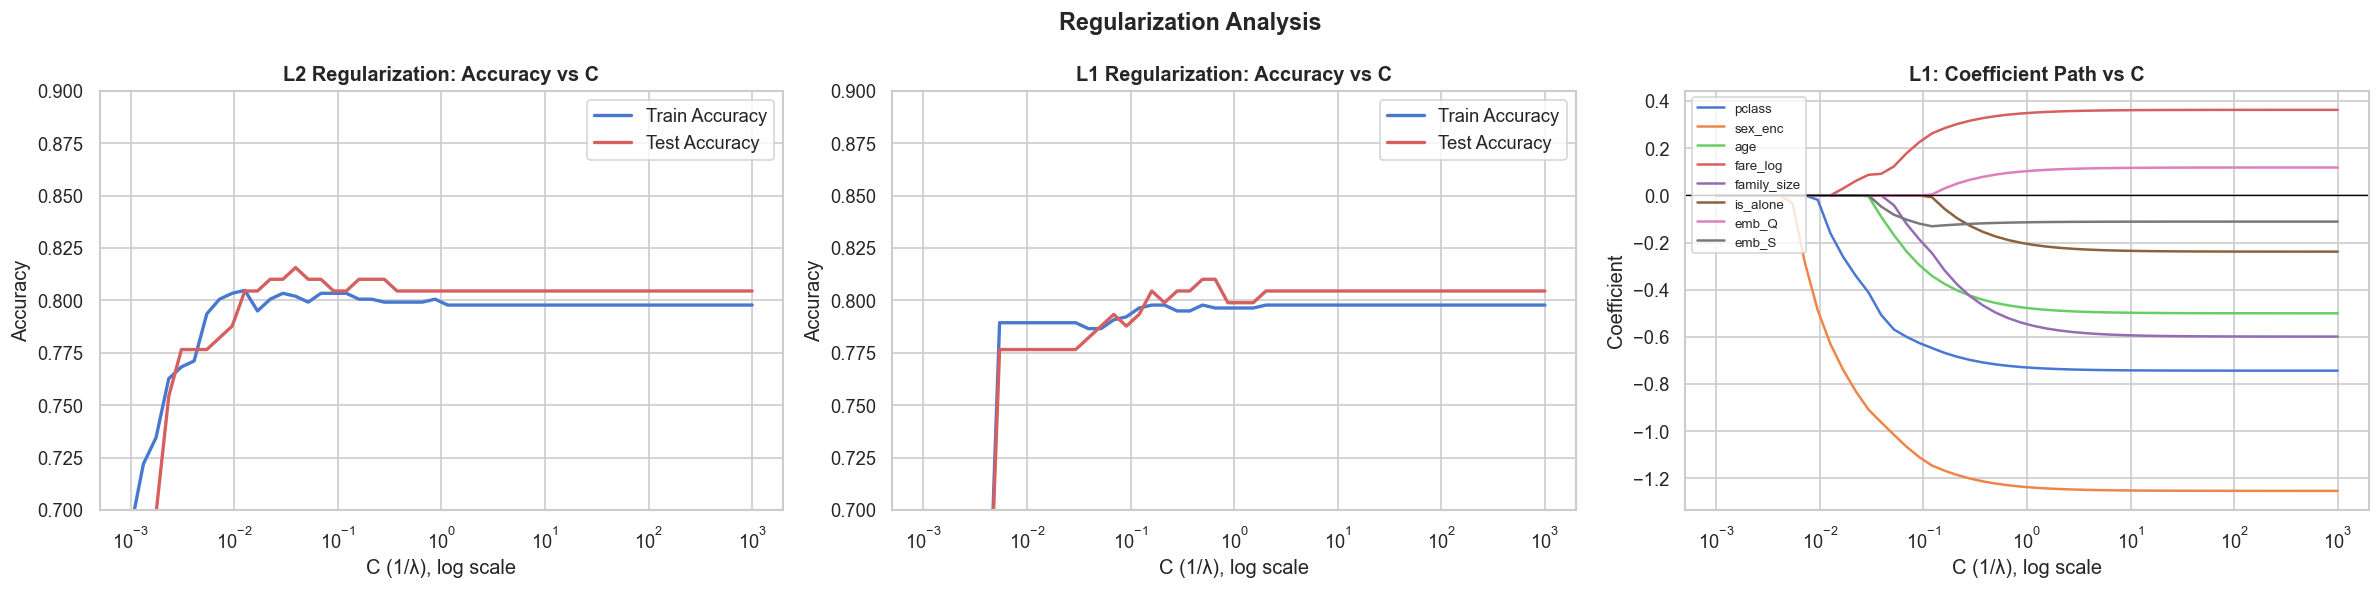

In [16]:
C_values = np.logspace(-3, 3, 50)

train_accs_l2, test_accs_l2 = [], []
train_accs_l1, test_accs_l1 = [], []
coefs_l1 = []

for C in C_values:
    # L2
    m_l2 = LogisticRegression(C=C, penalty='l2', max_iter=1000, random_state=42)
    m_l2.fit(X_train, y_train)
    train_accs_l2.append(m_l2.score(X_train, y_train))
    test_accs_l2.append(m_l2.score(X_test, y_test))
    
    # L1
    m_l1 = LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
    m_l1.fit(X_train, y_train)
    train_accs_l1.append(m_l1.score(X_train, y_train))
    test_accs_l1.append(m_l1.score(X_test, y_test))
    coefs_l1.append(m_l1.coef_[0])

coefs_l1 = np.array(coefs_l1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# L2: Accuracy vs C
axes[0].plot(C_values, train_accs_l2, 'b-', linewidth=2, label='Train Accuracy')
axes[0].plot(C_values, test_accs_l2, 'r-', linewidth=2, label='Test Accuracy')
axes[0].set_xscale('log')
axes[0].set_title('L2 Regularization: Accuracy vs C', fontsize=12, fontweight='bold')
axes[0].set_xlabel('C (1/λ), log scale')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0.7, 0.9)

# L1: Accuracy vs C
axes[1].plot(C_values, train_accs_l1, 'b-', linewidth=2, label='Train Accuracy')
axes[1].plot(C_values, test_accs_l1, 'r-', linewidth=2, label='Test Accuracy')
axes[1].set_xscale('log')
axes[1].set_title('L1 Regularization: Accuracy vs C', fontsize=12, fontweight='bold')
axes[1].set_xlabel('C (1/λ), log scale')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_ylim(0.7, 0.9)

# L1 Coefficient path
for i, feat in enumerate(feature_cols):
    axes[2].plot(C_values, coefs_l1[:, i], linewidth=1.5, label=feat)
axes[2].set_xscale('log')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('L1: Coefficient Path vs C', fontsize=12, fontweight='bold')
axes[2].set_xlabel('C (1/λ), log scale')
axes[2].set_ylabel('Coefficient')
axes[2].legend(fontsize=8, loc='upper left')

plt.suptitle('Regularization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Model Evaluation

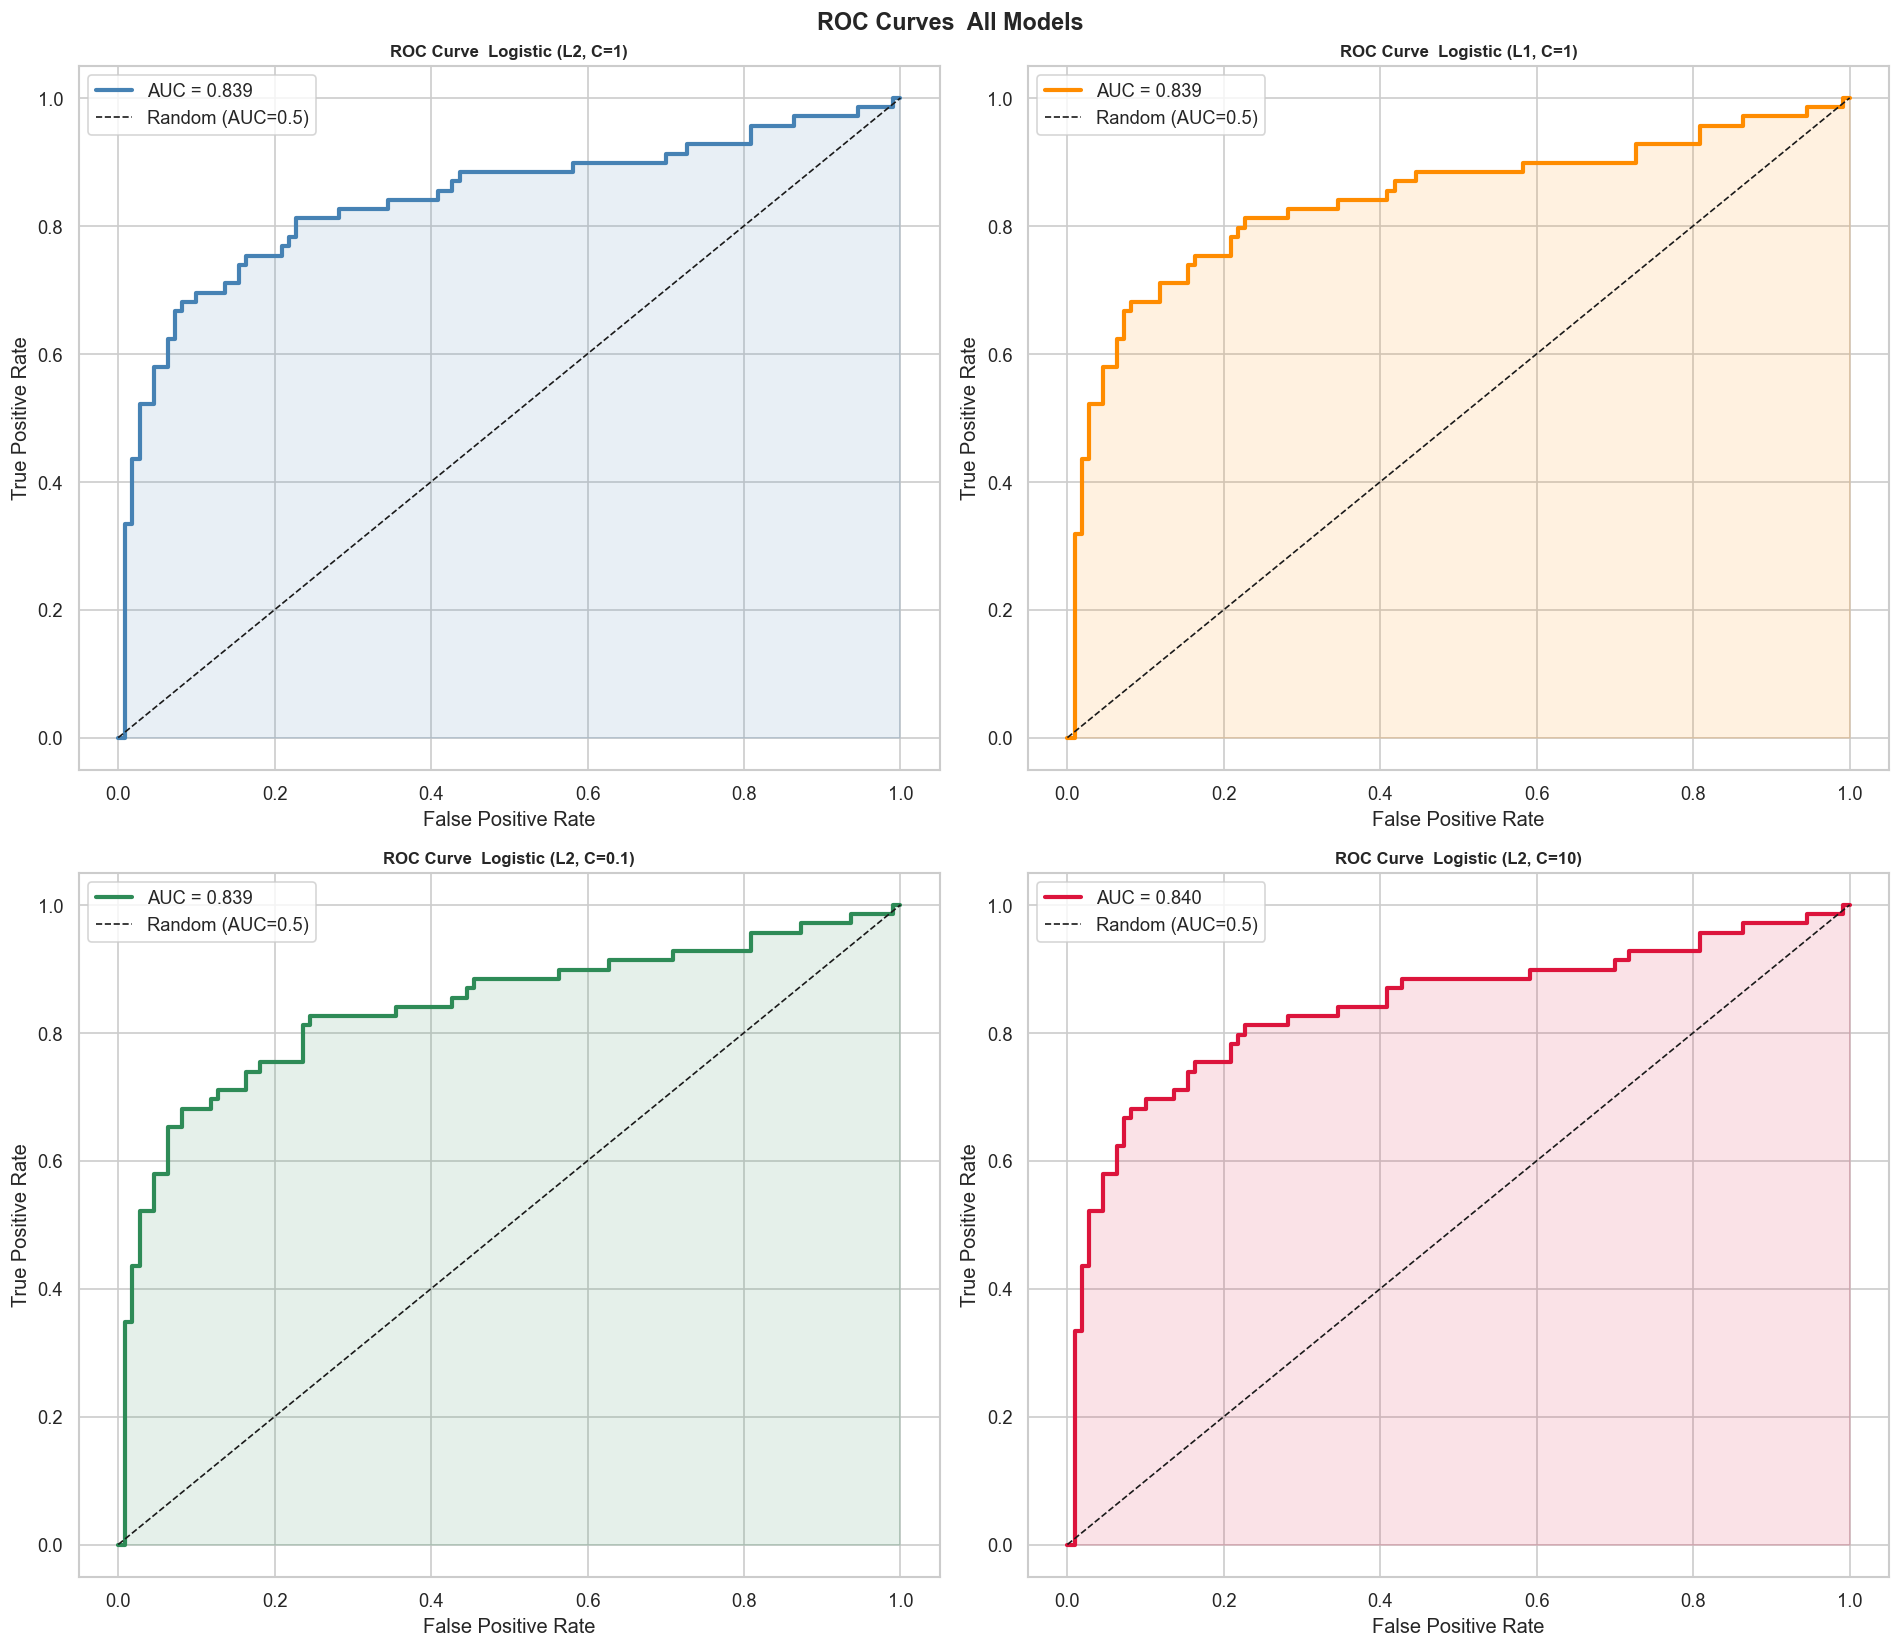

               Model  Accuracy  ROC-AUC
  Logistic (L2, C=1)    0.8045   0.8393
  Logistic (L1, C=1)    0.7989   0.8390
Logistic (L2, C=0.1)    0.8045   0.8391
 Logistic (L2, C=10)    0.8045   0.8399


In [17]:
# Train final models
models_eval = {
    'Logistic (L2, C=1)': LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42),
    'Logistic (L1, C=1)': LogisticRegression(penalty='l1', C=1, solver='liblinear', max_iter=1000, random_state=42),
    'Logistic (L2, C=0.1)': LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42),
    'Logistic (L2, C=10)': LogisticRegression(penalty='l2', C=10, max_iter=1000, random_state=42),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

results_clf = []
colors_roc = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for i, (name, model) in enumerate(models_eval.items()):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    
    results_clf.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'ROC-AUC': round(roc_auc, 4)
    })
    
    axes[i].plot(fpr, tpr, color=colors_roc[i], linewidth=2.5,
                 label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
    axes[i].fill_between(fpr, tpr, alpha=0.12, color=colors_roc[i])
    axes[i].set_title(f'ROC Curve  {name}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend()

plt.suptitle('ROC Curves  All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(pd.DataFrame(results_clf).to_string(index=False))


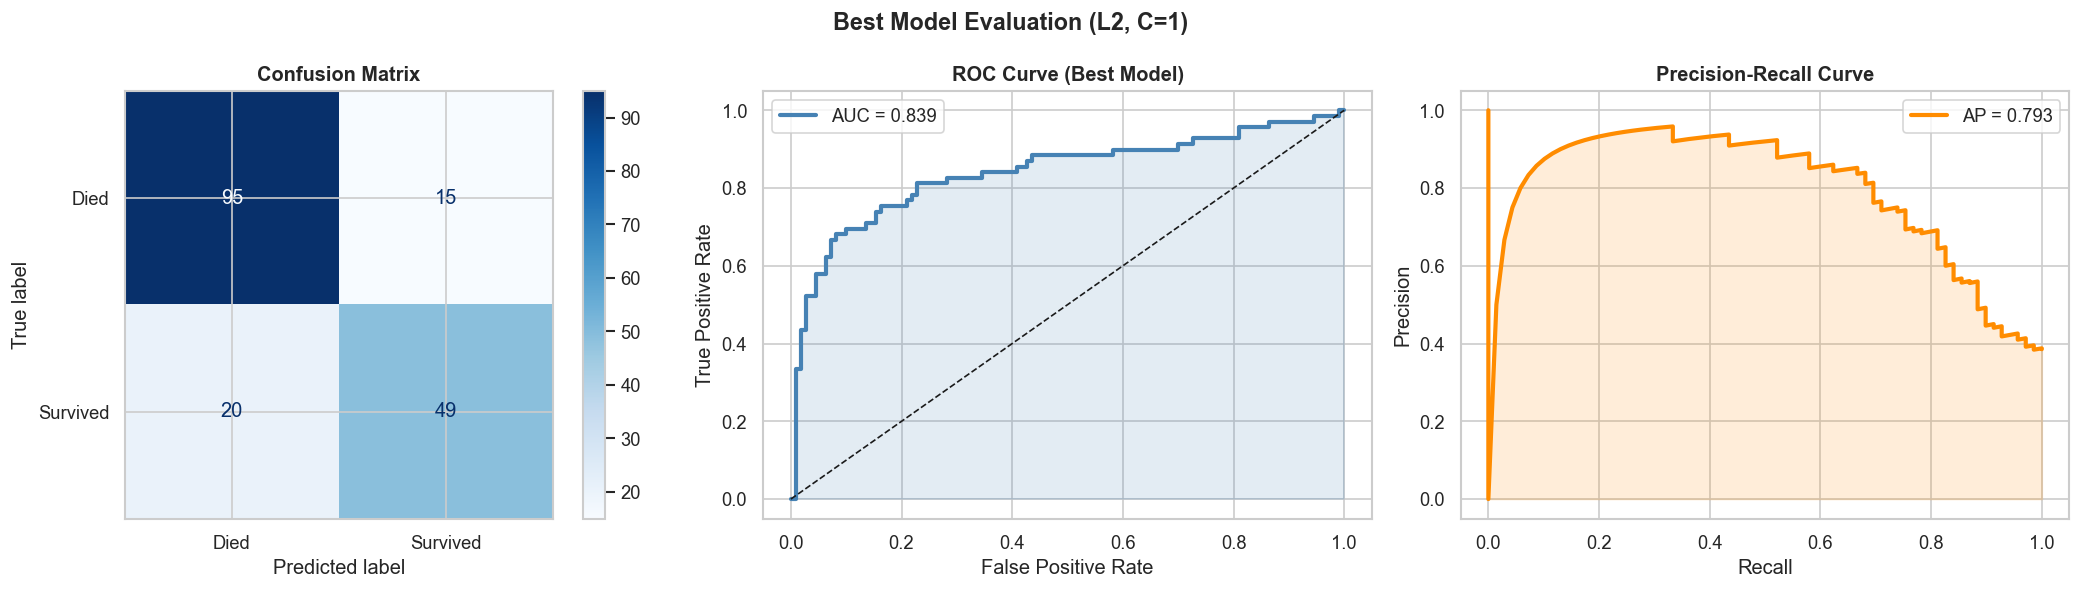

Classification report:
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [18]:
# Best model detailed evaluation
best_model = LogisticRegression(penalty='l2', C=1, max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                        display_labels=['Died', 'Survived'],
                                        cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='steelblue')
axes[1].set_title('ROC Curve (Best Model)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
avg_prec = average_precision_score(y_test, y_proba_best)
axes[2].plot(recall, precision, color='darkorange', linewidth=2.5,
             label=f'AP = {avg_prec:.3f}')
axes[2].fill_between(recall, precision, alpha=0.15, color='darkorange')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.suptitle('Best Model Evaluation (L2, C=1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification report:')
print(classification_report(y_test, y_pred_best, target_names=['Died', 'Survived']))


## 9. Feature Importance (Coefficients & Odds Ratios)

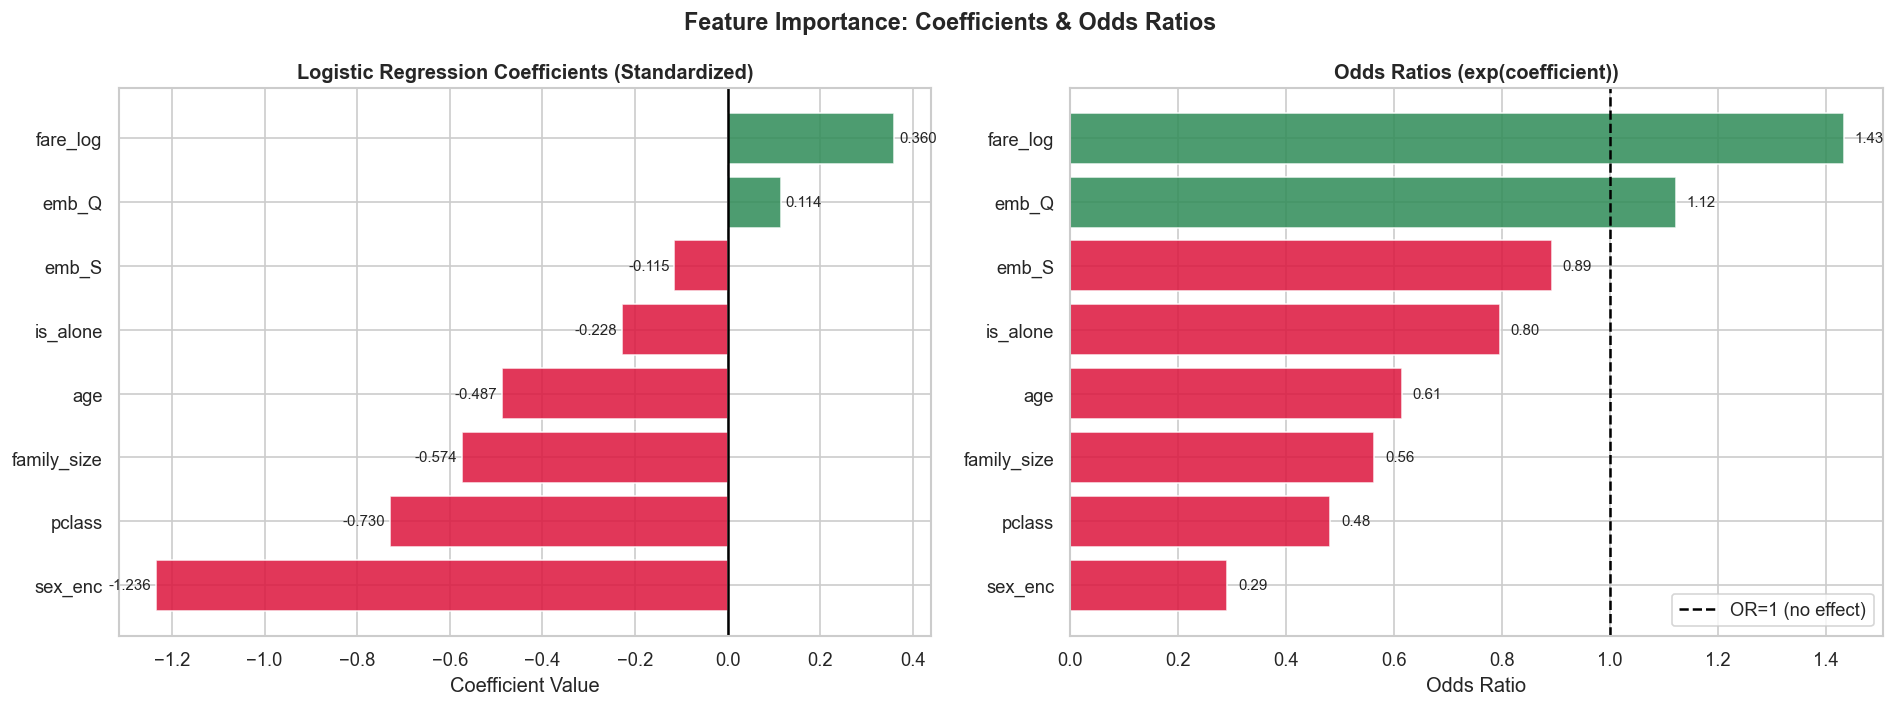

Odds ratios:

    Feature  Coefficient  Odds Ratio
   fare_log     0.359863    1.433134
      emb_Q     0.114443    1.121248
      emb_S    -0.114820    0.891527
   is_alone    -0.228349    0.795847
        age    -0.486795    0.614593
family_size    -0.574429    0.563026
     pclass    -0.730158    0.481833
    sex_enc    -1.235576    0.290667


In [19]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_model.coef_[0],
    'Odds Ratio': np.exp(best_model.coef_[0])
}).sort_values('Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficients
colors_coef = ['crimson' if c < 0 else 'seagreen' for c in coef_df['Coefficient']]
bars = axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
                    color=colors_coef, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1.5)
for bar, v in zip(bars, coef_df['Coefficient']):
    axes[0].text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
axes[0].set_title('Logistic Regression Coefficients (Standardized)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Odds Ratios
colors_or = ['crimson' if o < 1 else 'seagreen' for o in coef_df['Odds Ratio']]
bars2 = axes[1].barh(coef_df['Feature'], coef_df['Odds Ratio'],
                     color=colors_or, edgecolor='white', alpha=0.85)
axes[1].axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR=1 (no effect)')
for bar, v in zip(bars2, coef_df['Odds Ratio']):
    axes[1].text(v + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', fontsize=9)
axes[1].set_title('Odds Ratios (exp(coefficient))', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Odds Ratio')
axes[1].legend()

plt.suptitle('Feature Importance: Coefficients & Odds Ratios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Odds ratios:')



print()
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio']].sort_values('Odds Ratio', ascending=False).to_string(index=False))


### 9.1 Predicted Probabilities & Calibration

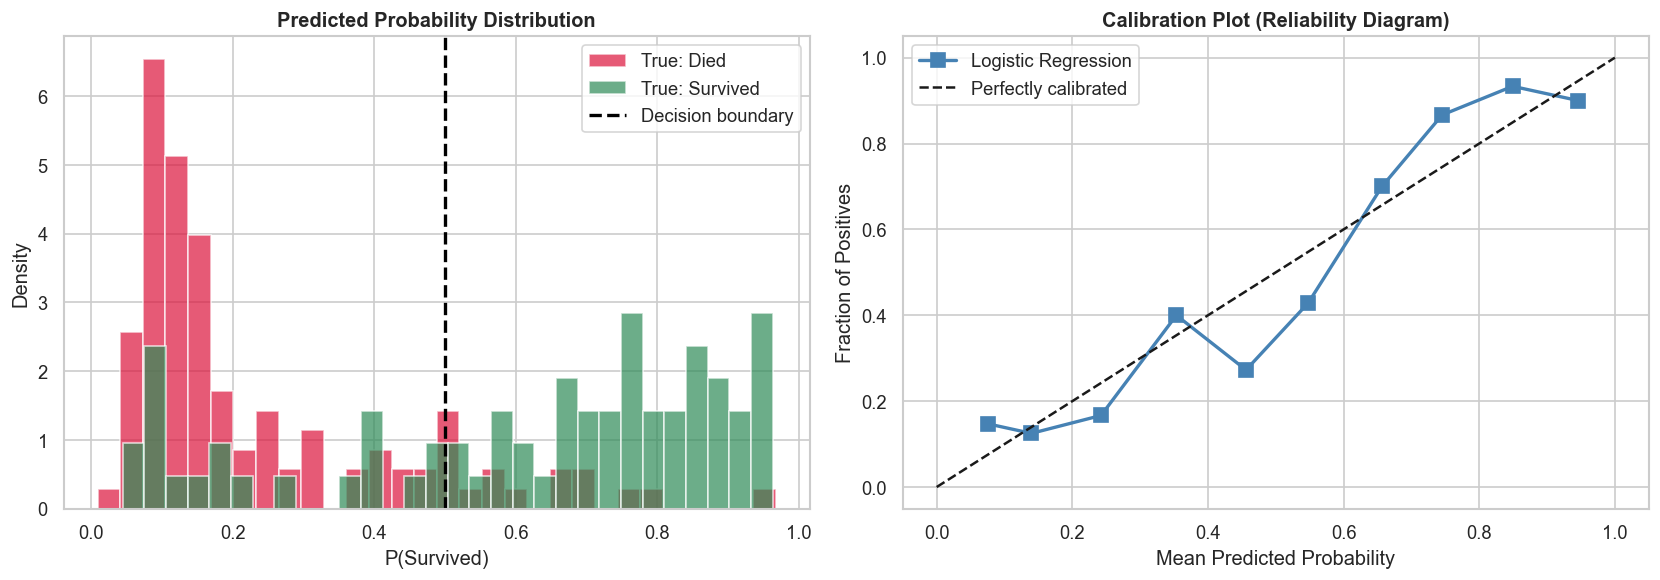

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability histogram
axes[0].hist(y_proba_best[y_test == 0], bins=30, alpha=0.7, color='crimson',
             label='True: Died', density=True, edgecolor='white')
axes[0].hist(y_proba_best[y_test == 1], bins=30, alpha=0.7, color='seagreen',
             label='True: Survived', density=True, edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
axes[0].set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(Survived)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Calibration plot
from sklearn.calibration import calibration_curve
fraction_pos, mean_predicted = calibration_curve(y_test, y_proba_best, n_bins=10)
axes[1].plot(mean_predicted, fraction_pos, 's-', color='steelblue', linewidth=2,
             markersize=8, label='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfectly calibrated')
axes[1].set_title('Calibration Plot (Reliability Diagram)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend()

plt.tight_layout()
plt.show()



